#  Load clean master data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

master_df = pd.read_csv('D:/Varanasi_Air_Quality/data/processed/master_clean.csv',
                         parse_dates=['Timestamp'])

print(" Master data loaded")
print(f"Total rows    : {len(master_df):,}")
print(f"Total columns : {master_df.shape[1]}")
print(f"Date range    : {master_df['Timestamp'].min()} → {master_df['Timestamp'].max()}")
print(f"Stations      : {master_df['station'].unique().tolist()}")

 Master data loaded
Total rows    : 35,040
Total columns : 22
Date range    : 2025-01-01 00:00:00 → 2025-12-31 23:00:00
Stations      : ['ardhali_bazar', 'bhelupur', 'bhu_iesd', 'maldahiya']


#  Basic statistics for all pollutants

In [3]:
pollutants = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO (µg/m³)',
              'SO2 (µg/m³)', 'CO (mg/m³)', 'Ozone (µg/m³)',
              'Benzene (µg/m³)', 'AT (°C)', 'RH (%)', 
              'WS (m/s)', 'SR (W/mt2)']

for station in master_df['station'].unique():
    df_s = master_df[master_df['station'] == station]
    print(f"\n{'='*55}")
    print(f"  STATION : {station.upper()}")
    print(f"{'='*55}")
    print(df_s[pollutants].describe().round(2))


  STATION : ARDHALI_BAZAR
       PM2.5 (µg/m³)  PM10 (µg/m³)  NO (µg/m³)  SO2 (µg/m³)  CO (mg/m³)  \
count        8607.00       8603.00     8760.00      8016.00     8621.00   
mean           31.82         69.01       12.67        13.25        0.25   
std            25.02         57.03       14.34         3.59        0.15   
min             2.00          3.25        0.12         0.70        0.00   
25%            15.75         31.33        4.30        11.72        0.18   
50%            25.25         50.00        5.60        13.69        0.21   
75%            40.75         87.25       11.28        14.54        0.28   
max           397.00        508.00      120.74       109.60        2.12   

       Ozone (µg/m³)  Benzene (µg/m³)  AT (°C)   RH (%)  WS (m/s)  SR (W/mt2)  
count        6139.00          8760.00  6062.00  6037.00   6064.00     6024.00  
mean           26.31             0.82    25.80    65.22      0.90      129.35  
std            12.88             0.42     6.73    17.22  

# Missing values remaining after imputation

In [4]:
print("MISSING VALUES REMAINING AFTER IMPUTATION")
print()

for station in master_df['station'].unique():
    df_s = master_df[master_df['station'] == station]
    print(f"\nStation : {station.upper()}")
    missing = df_s[pollutants].isnull().sum()
    missing_pct = (df_s[pollutants].isnull().sum() / len(df_s) * 100).round(1)
    summary = pd.DataFrame({
        'Missing Count' : missing,
        'Missing %'     : missing_pct
    })
    
    # Only show parameters that still have missing values
    summary = summary[summary['Missing Count'] > 0]
    if len(summary) == 0:
        print("  No missing values remaining ")
    else:
        print(summary)

MISSING VALUES REMAINING AFTER IMPUTATION


Station : ARDHALI_BAZAR
               Missing Count  Missing %
PM2.5 (µg/m³)            153        1.7
PM10 (µg/m³)             157        1.8
SO2 (µg/m³)              744        8.5
CO (mg/m³)               139        1.6
Ozone (µg/m³)           2621       29.9
AT (°C)                 2698       30.8
RH (%)                  2723       31.1
WS (m/s)                2696       30.8
SR (W/mt2)              2736       31.2

Station : BHELUPUR
               Missing Count  Missing %
PM2.5 (µg/m³)           1237       14.1
PM10 (µg/m³)             136        1.6
CO (mg/m³)                20        0.2
Ozone (µg/m³)            554        6.3
AT (°C)                   90        1.0
RH (%)                    90        1.0
WS (m/s)                  91        1.0
SR (W/mt2)                35        0.4

Station : BHU_IESD
               Missing Count  Missing %
PM2.5 (µg/m³)           1151       13.1
PM10 (µg/m³)             715        8.2
CO (mg/m³)  


#  Which station has best and worst data quality

In [5]:
print("STATION DATA QUALITY RANKING")
print("="*55)
print("(Lower missing % = Better data quality)")
print()

quality = []
for station in master_df['station'].unique():
    df_s = master_df[master_df['station'] == station]
    total_missing = df_s[pollutants].isnull().sum().sum()
    total_values  = df_s[pollutants].size
    missing_pct   = round(total_missing / total_values * 100, 2)
    quality.append({
        'Station'        : station,
        'Total Missing'  : total_missing,
        'Missing %'      : missing_pct
    })
quality_df = pd.DataFrame(quality).sort_values('Missing %')
quality_df['Rank'] = range(1, 5)
quality_df['Quality'] = ['Best', 'Good', 'Fair', 'Worst']
print(quality_df.to_string(index=False))

STATION DATA QUALITY RANKING
(Lower missing % = Better data quality)

      Station  Total Missing  Missing %  Rank Quality
    maldahiya            692       0.72     1    Best
     bhelupur           2253       2.34     2    Good
     bhu_iesd           2751       2.85     3    Fair
ardhali_bazar          14667      15.22     4   Worst


# Monthly missing data pattern
Showing as percentage so it is easier to understand  

Was any sensor down for long periods in specific months?

In [6]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

check = {
    'ardhali_bazar' : ['Ozone (µg/m³)', 'AT (°C)', 
                        'RH (%)', 'WS (m/s)', 'SR (W/mt2)'],
    'bhelupur'      : ['PM2.5 (µg/m³)'],
    'bhu_iesd'      : ['PM2.5 (µg/m³)'],
}

for station, params in check.items():
    df_s = master_df[master_df['station'] == station]
    
    print(f"\n{'='*55}")
    print(f"  STATION : {station.upper()}")
    print(f"{'='*55}")
    
    for param in params:
        monthly = df_s.groupby('month')[param].apply(
            lambda x: round(x.isnull().sum() / len(x) * 100, 1)
        )
        monthly.index = month_names
        print(f"\n  {param} — missing % per month:")
        print(f"{monthly.to_string()}")


  STATION : ARDHALI_BAZAR

  Ozone (µg/m³) — missing % per month:
Jan      2.6
Feb      0.0
Mar      0.0
Apr      0.1
May      3.2
Jun      0.8
Jul      4.4
Aug     98.9
Sep     97.8
Oct    100.0
Nov     48.3
Dec      0.8

  AT (°C) — missing % per month:
Jan      4.4
Feb      0.4
Mar      1.1
Apr      1.2
May      4.0
Jun      1.9
Jul      3.6
Aug     99.9
Sep    100.0
Oct    100.0
Nov     48.1
Dec      2.8

  RH (%) — missing % per month:
Jan      4.4
Feb      0.4
Mar      1.1
Apr      1.2
May      4.0
Jun      1.9
Jul      3.8
Aug     99.9
Sep    100.0
Oct    100.0
Nov     48.1
Dec      6.0

  WS (m/s) — missing % per month:
Jan      4.4
Feb      0.4
Mar      0.9
Apr      1.2
May      4.0
Jun      1.9
Jul      3.6
Aug     99.7
Sep    100.0
Oct    100.0
Nov     48.1
Dec      2.8

  SR (W/mt2) — missing % per month:
Jan      4.4
Feb      0.4
Mar      1.1
Apr      1.2
May      4.0
Jun      1.9
Jul      3.6
Aug     99.7
Sep    100.0
Oct    100.0
Nov     53.3
Dec      3.0

  STATION : B

# What Insights You Will Find
#### Insight 1 — Sensor downtime period
If AT, RH, WS, SR all show high missing values in the same months at Ardhali Bazar — you can confidently say the meteorological sensor unit was down during those months. Write this in your report as a data limitation finding.
#### Insight 2 — PM2.5 sensor reliability
If Bhelupur and BHU IESD show PM2.5 missing concentrated in specific months — those months' pollution data is incomplete and conclusions drawn from those months should be treated carefully.
#### Insight 3 — Impact on analysis
If the Ardhali Bazar met sensor was down during Winter months — your meteorological analysis for that station will be incomplete for the most critical season. This is important to mention in limitations.
#### Insight 4 — Data quality comparison
Maldahiya and Bhelupur have relatively complete meteorological data — so your met analysis will be more reliable for those stations than Ardhali Bazar.

# Distribution of each pollutant using Histogram

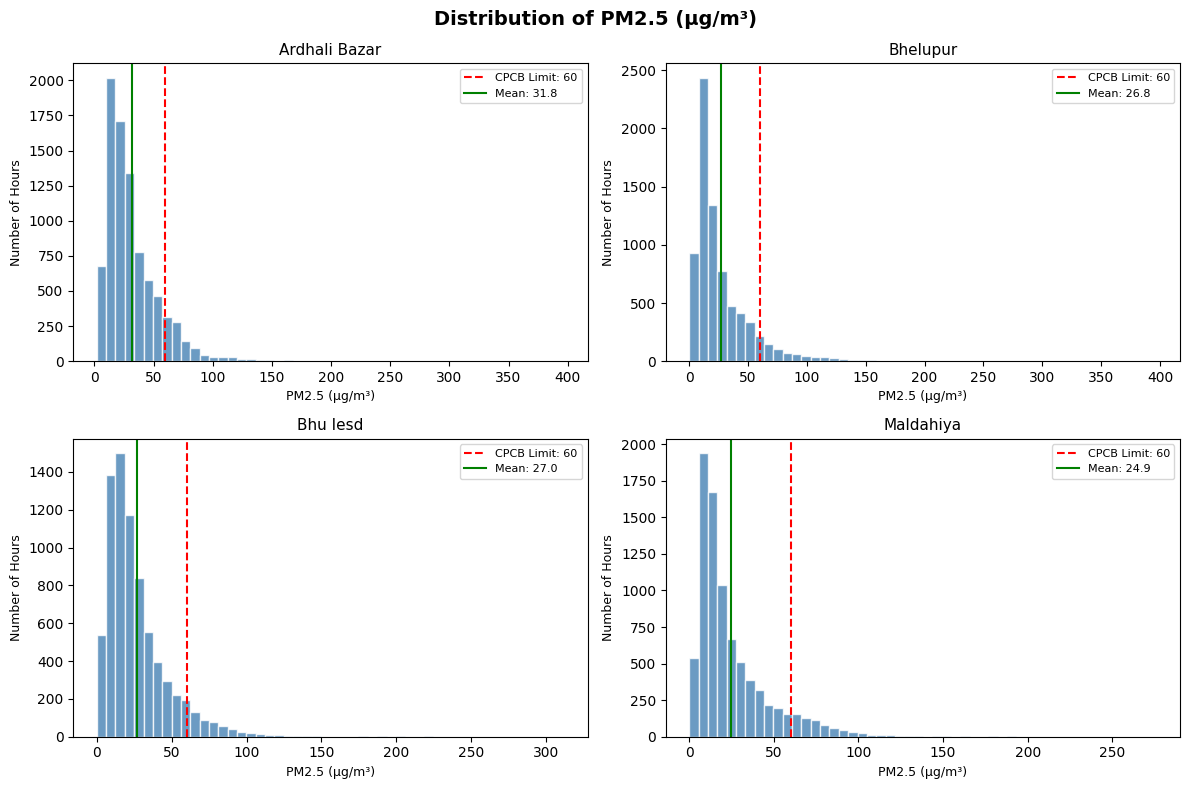

 Distribution chart saved for PM2.5 (µg/m³)


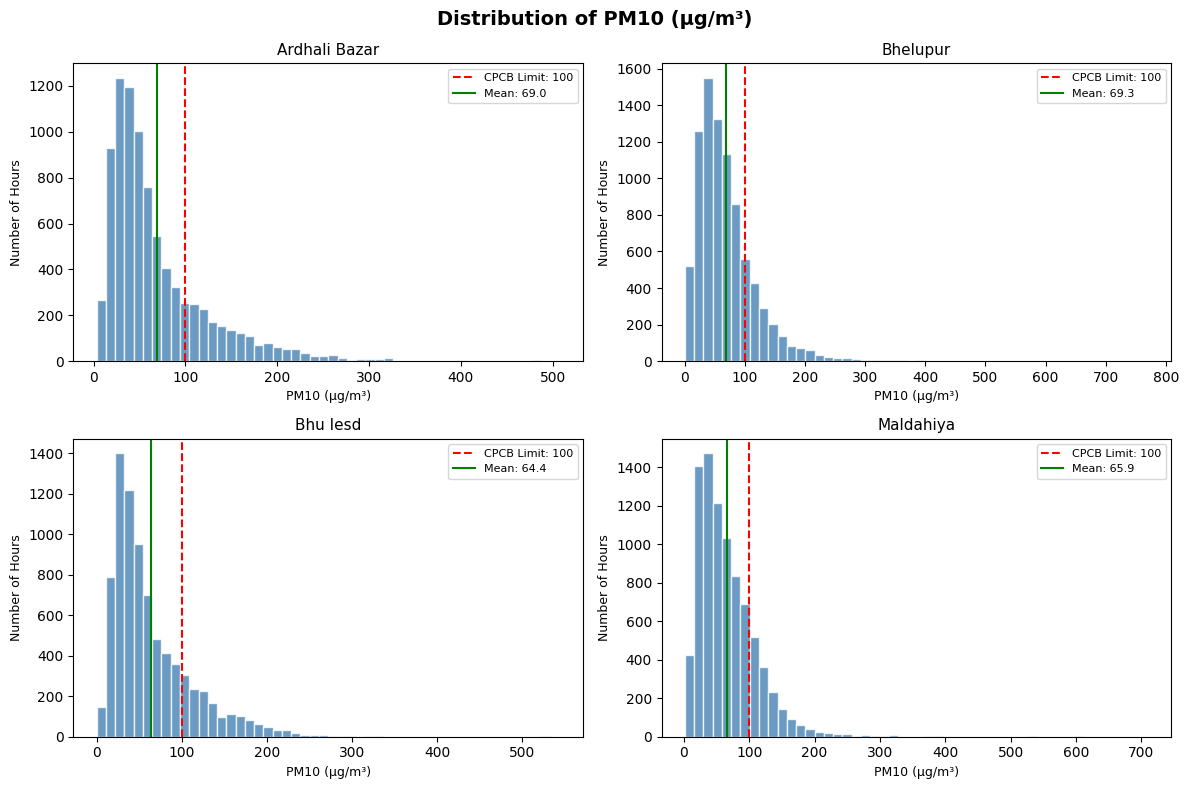

 Distribution chart saved for PM10 (µg/m³)


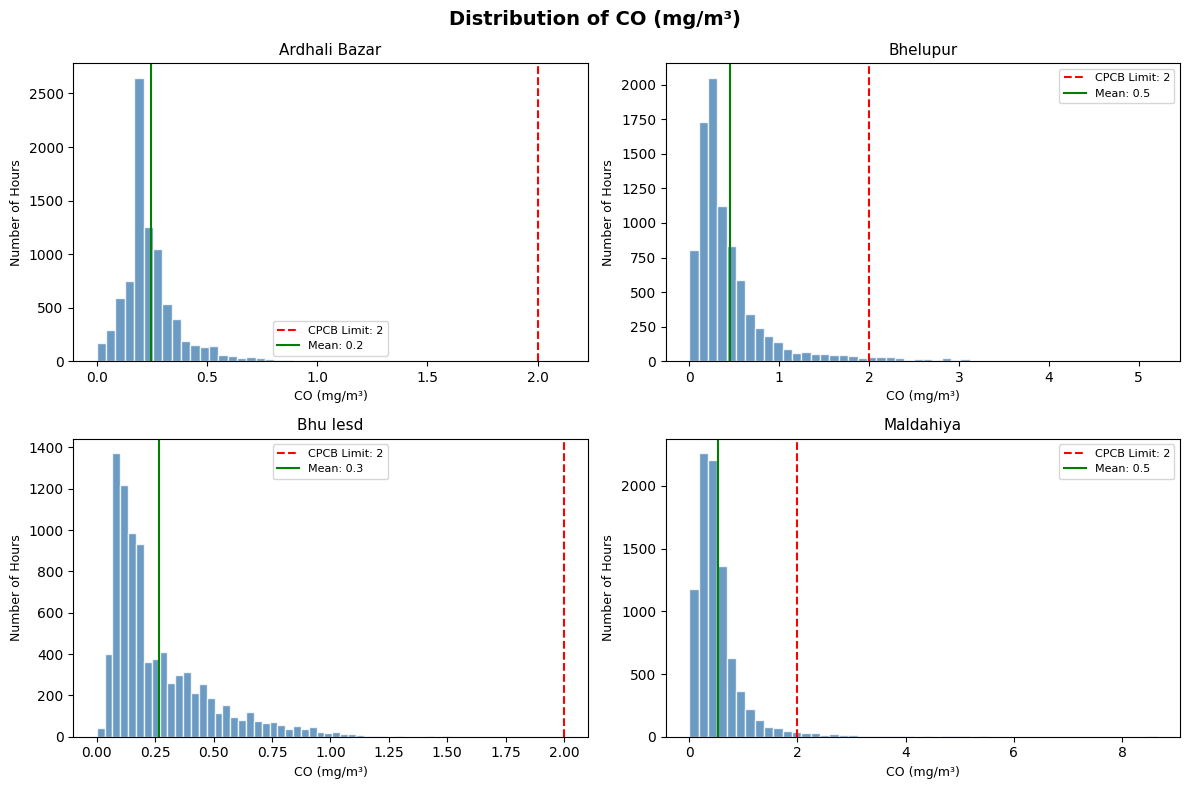

 Distribution chart saved for CO (mg/m³)


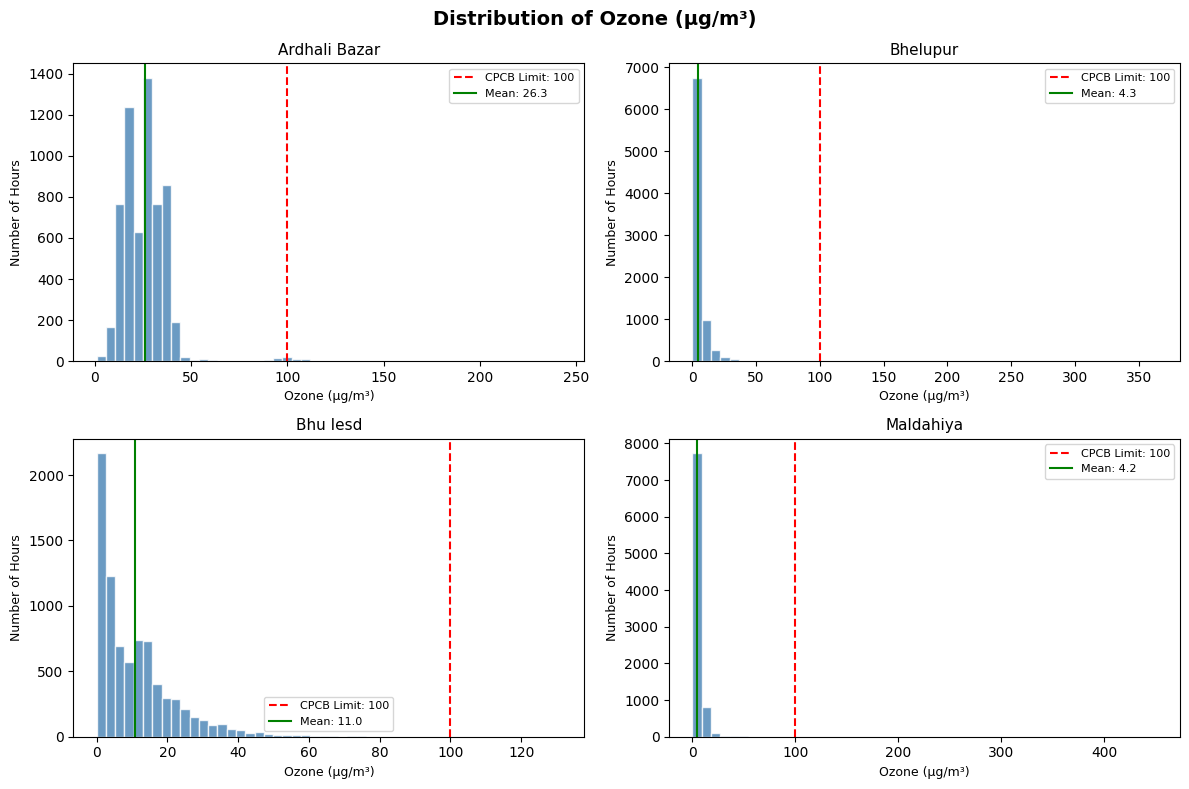

 Distribution chart saved for Ozone (µg/m³)


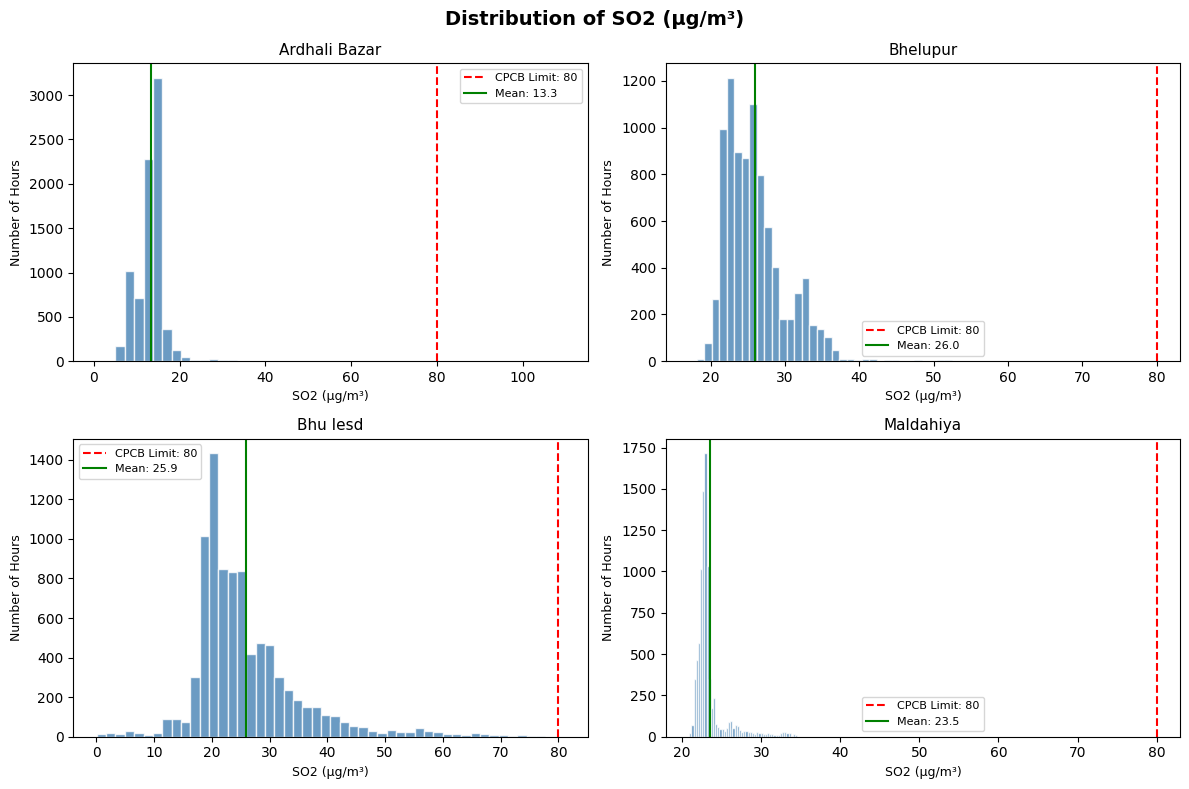

 Distribution chart saved for SO2 (µg/m³)


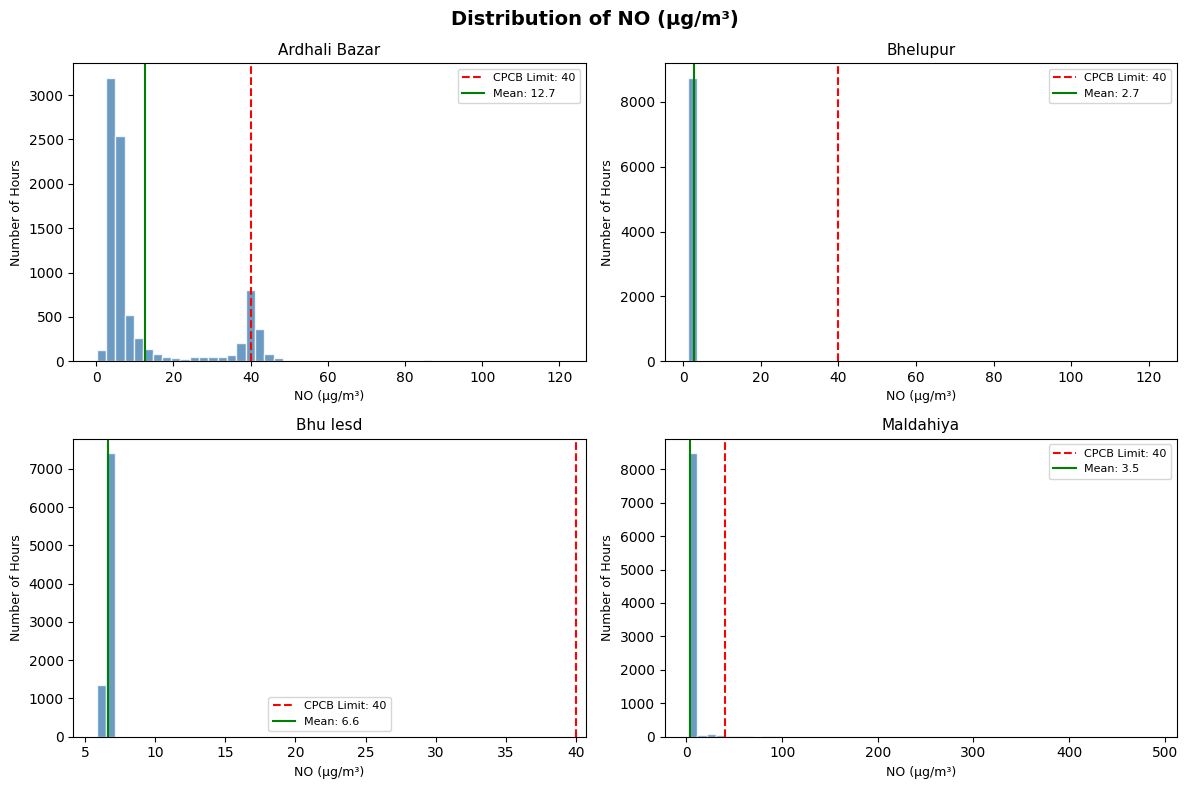

 Distribution chart saved for NO (µg/m³)


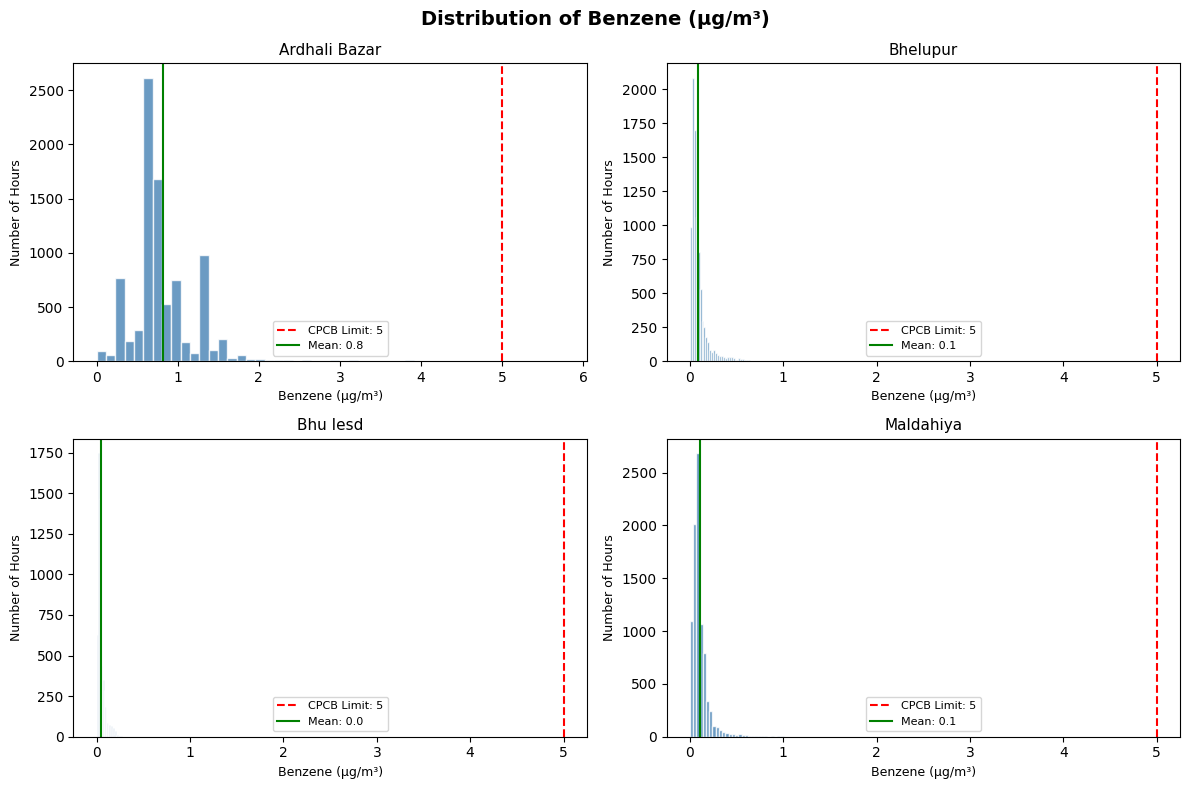

 Distribution chart saved for Benzene (µg/m³)


In [7]:
pollutants_to_plot = [
    'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'CO (mg/m³)',
    'Ozone (µg/m³)', 'SO2 (µg/m³)', 'NO (µg/m³)',
    'Benzene (µg/m³)'
]

# Create subfolder first
os.makedirs('D:/Varanasi_Air_Quality/outputs/charts/univariate', exist_ok=True)

stations_list = master_df['station'].unique()

for pollutant in pollutants_to_plot:

    # Create one figure with 4 subplots - one per station
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'Distribution of {pollutant}', 
                 fontsize=14, fontweight='bold')

    # Flatten axes so we can loop through them easily
    axes = axes.flatten()

    for i, station in enumerate(stations_list):

        # Filter data for this station
        df_s = master_df[master_df['station'] == station][pollutant].dropna()

        # Plot histogram
        axes[i].hist(df_s, bins=50, color='steelblue', 
                     edgecolor='white', alpha=0.8)

        # Add CPCB limit line where applicable
        cpcb_limits = {
            'PM2.5 (µg/m³)' : 60,
            'PM10 (µg/m³)'  : 100,
            'CO (mg/m³)'    : 2,
            'Ozone (µg/m³)' : 100,
            'SO2 (µg/m³)'   : 80,
            'NO (µg/m³)'    : 40,
            'Benzene (µg/m³)': 5,
        }

        if pollutant in cpcb_limits:
            axes[i].axvline(x=cpcb_limits[pollutant], 
                           color='red', linestyle='--', 
                           linewidth=1.5,
                           label=f'CPCB Limit: {cpcb_limits[pollutant]}')
            axes[i].legend(fontsize=8)

        # Labels and title
        axes[i].set_title(station.replace('_', ' ').title(), fontsize=11)
        axes[i].set_xlabel(pollutant, fontsize=9)
        axes[i].set_ylabel('Number of Hours', fontsize=9)

        # Add mean line
        axes[i].axvline(x=df_s.mean(), color='green', 
                       linestyle='-', linewidth=1.5,
                       label=f'Mean: {df_s.mean():.1f}')
        axes[i].legend(fontsize=8)

    plt.tight_layout()

    # Save chart
    filename = pollutant.split(' ')[0].replace('.', '')
    plt.savefig(f'D:/Varanasi_Air_Quality/outputs/charts/univariate/distribution_{filename}.png', 
            dpi=150, bbox_inches='tight')
    plt.show()
    print(f" Distribution chart saved for {pollutant}")

# Time Series Plot of PM2.5 for all 4 stations

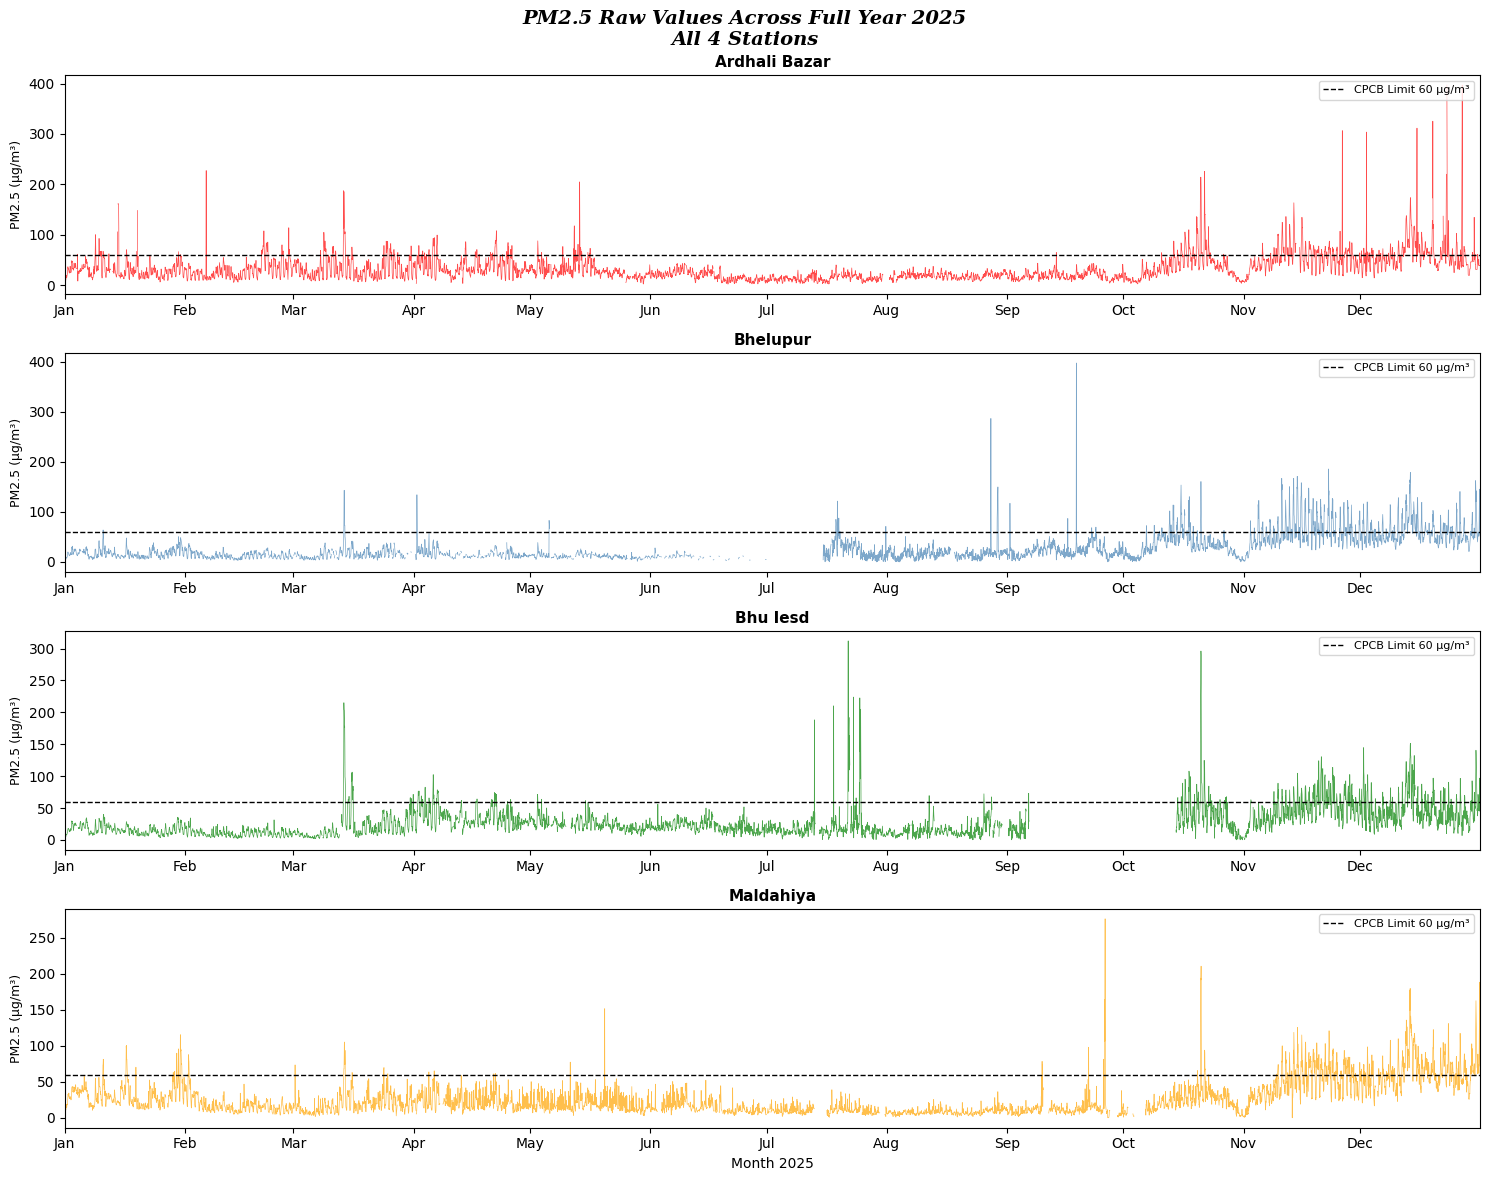

 PM2.5 time series chart saved


In [8]:
import matplotlib.dates as mdates

os.makedirs('D:/Varanasi_Air_Quality/outputs/charts/univariate', exist_ok=True)

# Color for each station
colors = {
    'bhelupur'     : 'steelblue',
    'ardhali_bazar': 'red',
    'bhu_iesd'     : 'green',
    'maldahiya'    : 'orange'
}

# Plot all 4 stations in one figure
fig, axes = plt.subplots(4, 1, figsize=(15, 12))
fig.suptitle('PM2.5 Raw Values Across Full Year 2025\nAll 4 Stations',
             fontsize=14, fontweight='bold',fontfamily='serif',fontstyle='italic')

for i, station in enumerate(master_df['station'].unique()):

    # Filter data for this station
    df_s = master_df[master_df['station'] == station]

    # Plot raw hourly PM2.5
    axes[i].plot(df_s['Timestamp'],
                 df_s['PM2.5 (µg/m³)'],
                 color=colors[station],
                 linewidth=0.5,        # thin line because 8760 points
                 alpha=0.7)

    # Add CPCB safe limit line
    axes[i].axhline(y=60,
                    color='black',
                    linestyle='--',
                    linewidth=1,
                    label='CPCB Limit 60 µg/m³')

    # Title and labels
    axes[i].set_title(station.replace('_',' ').title(), fontsize=11,fontweight='bold')
    axes[i].set_ylabel('PM2.5 (µg/m³)', fontsize=9)
    axes[i].legend(fontsize=8, loc='upper right')

    # Format x axis to show month names clearly
    axes[i].xaxis.set_major_locator(mdates.MonthLocator())           # Shows one tick per month
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b'))    # Shows month name like Jan, Feb, Mar instead of 2025-01-01
    axes[i].tick_params(axis='x', rotation=0)                        # Keeps month names horizontal not tilted

    # Add season labels on x axis
    axes[i].set_xlim(df_s['Timestamp'].min(),
                     df_s['Timestamp'].max())

# Only show x axis label on bottom plot
axes[3].set_xlabel('Month 2025', fontsize=10)

plt.tight_layout()
plt.savefig('D:/Varanasi_Air_Quality/outputs/charts/univariate/timeseries_pm25.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" PM2.5 time series chart saved")